<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8015/blob/main/src/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Datos (EDA) y Diagnóstico de Calidad
## Proyecto 03: Sistema de Tarificación Dinámica y Copiloto de Subarriendo (CDMX)
### UTEC Posgrado · Maestría en Ciencia de Datos e Inteligencia Artificial
* **Curso:** Proyecto Integrador I · Semestre 2026-II
* **Equipo:** Herles Alejandro Pinedo (Data Scientist) · José Carlos Nomberto (ML Engineer) · David Jimenez (Product Lead)
* **Metodología:** CRISP-DM · Etapa E2: Comprensión de los Datos (*Data Understanding*)

---
## 1. Contexto de Negocio y Objetivos del EDA

En modelos de subarriendo profesional (*Master-Lease / Rental Arbitrage*), una empresa arrienda departamentos bajo contratos fijos tradicionales (12 a 24 meses) para operarlos en plataformas de corta estancia como Airbnb. El éxito financiero depende de capturar el diferencial entre el costo fijo y el ingreso variable neto (*RevPAN: Revenue per Available Night*). 

Firmar un contrato en una propiedad subóptima genera un costo de oportunidad de más de **$185,000 MXN anuales** por activo. Este análisis exploratorio tiene como objetivo desentrañar los factores empíricos que determinan la viabilidad comercial y la calidad de los datos de oferta en Ciudad de México:

1. **Topografía y Densidad de la Oferta:** Evaluar la distribución espacial del mercado e identificar patrones de hiperconcentración territorial.
2. **Higiene Operativa del Inventario:** Detectar anomalías estructurales (anuncios inactivos, bloqueos defensivos y estancias no turísticas) que distorsionan los modelos.
3. **Determinantes Estructurales y Primas de Equipamiento:** Cuantificar el impacto del acondicionamiento inicial (aire acondicionado, terraza, espacio de trabajo) sobre las tarifas y noches ocupadas.
4. **Auditoría Dimensional de Calidad:** Diagnosticar exhaustivamente completitud (mecanismos MAR/MCAR), consistencia de tipos, valores atípicos y representatividad para sustentar el pipeline de preparación (E3).

---
## 2. Configuración del Entorno y Reproducibilidad

Cargamos las dependencias analíticas, fijamos semillas estocásticas globales (`SEED = 42`) y definimos estilos visuales de calidad editorial y paletas cromáticas accesibles.

In [1]:
import os
import sys
import gc
import re
import json
import time
import warnings
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from IPython.display import display, HTML

# Supresión de advertencias operativas
warnings.filterwarnings('ignore')

# Semilla de reproducibilidad global
SEED = 42
np.random.seed(SEED)

# Parámetros gráficos institucionales
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 5.5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.sans-serif': 'DejaVu Sans',
    'figure.autolayout': True
})

# Paleta cromática ejecutiva
C_NAVY   = '#1f4e79'     # Azul corporativo primario
C_TEAL   = '#1b9e77'     # Verde/teal: Métricas positivas o limpias
C_CORAL  = '#d95f02'     # Ámbar/naranja: Advertencias o atención
C_CRIMSON= '#e41a1c'     # Rojo: Inconsistencias o valores extremos
C_SLATE  = '#595959'     # Gris neutro de referencia

# Resolución de rutas dinámicas multiplataforma
def resolve_data_dir():
    candidates = [
        "../../dataset",
        "../dataset",
        "dataset",
        "data/raw",
        os.path.expanduser("~/Documents/MAESTRIA/Capstone Project/Proyecto/dataset")
    ]
    for p in candidates:
        if os.path.exists(os.path.join(p, "airbnb_listings.parquet")):
            return os.path.abspath(p)
    return "data/raw"

DATA_DIR = resolve_data_dir()
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs("src/figures", exist_ok=True)

print(f" Entorno inicializado | Directorio de datos: {DATA_DIR}")

 Entorno inicializado | Directorio de datos: /Users/herivera/Documents/MAESTRIA/Capstone Project/Proyecto/dataset


---
## 3. Ingesta y Profiling Relacional del Ecosistema de Datos

El universo analítico proviene del snapshot de Inside Airbnb para Ciudad de México (corte temporal: **15 de junio de 2026**). El repositorio se estructura en tres entidades relacionales:
* **Listings (`airbnb_listings.parquet`):** Granularidad a nivel de inmueble ofertado (31,430 propiedades, 90 atributos físicos y reputacionales).
* **Calendar (`airbnb_calendar.parquet`):** Granularidad diaria proyectada a 365 días (11.47 millones de registros de disponibilidad y restricciones).
* **Reviews (`airbnb_reviews.parquet`):** Evaluaciones históricas de huéspedes (1.72 millones de comentarios textuales).

In [2]:
t0 = time.time()
df_listings = pd.read_parquet(os.path.join(DATA_DIR, "airbnb_listings.parquet"))
df_calendar = pd.read_parquet(os.path.join(DATA_DIR, "airbnb_calendar.parquet"))
df_reviews  = pd.read_parquet(os.path.join(DATA_DIR, "airbnb_reviews.parquet"))
load_time = time.time() - t0

# Verificación de integridad relacional básica
dup_listings_pk = df_listings['id'].duplicated().sum()
parent_ids = set(df_listings['id'])
orphans_cal = (~df_calendar['listing_id'].isin(parent_ids)).sum()
orphans_rev = (~df_reviews['listing_id'].isin(parent_ids)).sum()

profiling_df = pd.DataFrame([
    {
        "Entidad": "Listings (Propiedades)",
        "Observaciones": f"{len(df_listings):,}",
        "Atributos": df_listings.shape[1],
        "Llave Primaria": "id",
        "Duplicados PK": dup_listings_pk,
        "Registros Huérfanos": "N/A (Entidad Padre)"
    },
    {
        "Entidad": "Calendar (Disponibilidad)",
        "Observaciones": f"{len(df_calendar):,}",
        "Atributos": df_calendar.shape[1],
        "Llave Primaria": "(listing_id, date)",
        "Duplicados PK": df_calendar.duplicated(subset=['listing_id', 'date']).sum(),
        "Registros Huérfanos": orphans_cal
    },
    {
        "Entidad": "Reviews (Comentarios)",
        "Observaciones": f"{len(df_reviews):,}",
        "Atributos": df_reviews.shape[1],
        "Llave Primaria": "id",
        "Duplicados PK": df_reviews['id'].duplicated().sum(),
        "Registros Huérfanos": orphans_rev
    }
])

display(profiling_df)
print(f" Ingesta completada en {load_time:.2f}s | Integridad referencial perfecta (0 registros huérfanos).")

,Entidad,Observaciones,Atributos,Llave Primaria,Duplicados PK,Registros Huérfanos
0,Listings (Propiedades),"31,430",90,id,0,N/A (Entidad Padre)
1,Calendar (Disponibilidad),"11,471,961",5,"(listing_id, date)",0,0
2,Reviews (Comentarios),"1,719,730",6,id,0,0


 Ingesta completada en 1.23s | Integridad referencial perfecta (0 registros huérfanos).


---
## 4. Saneamiento Técnico y Coerción de Tipos de Datos

Antes de proceder con el modelado exploratorio, resolvemos tres inconsistencias sintácticas inherentes a la recopilación de datos abiertos:
1. **Tarifas (`price`):** Codificadas como texto con prefijo monetario y comas (`$1,500.00`). Se transforman a formato numérico continuo (`float32`).
2. **Capacidad Sanitaria (`bathrooms_text`):** Expresada en descripciones mixtas (*"1.5 baths"*, *"private half-bath"*, *"shared bath"*). Extraemos el número real continuo (`bathrooms_num`) y aislamos una bandera binaria de baño compartido (`is_shared_bath`), factor crítico de depreciación en alquiler profesional.
3. **Coherencia Temporal:** Verificamos que la fecha de primera reseña sea anterior o igual a la última reseña registrada.

In [3]:
# 1. Limpieza de variables de moneda
def clean_currency(val):
    if pd.isna(val): return np.nan
    if isinstance(val, (int, float)): return float(val)
    cleaned = re.sub(r'[^\d.]', '', str(val))
    return float(cleaned) if cleaned else np.nan

df_listings['price_cleaned'] = df_listings['price'].apply(clean_currency)

# 2. Parseo estructurado de baños
def parse_bathrooms(text):
    if pd.isna(text): return np.nan, 0
    t = str(text).lower()
    is_shared = 1 if 'shared' in t else 0
    if 'half' in t: return 0.5, is_shared
    m = re.search(r'([\d.]+)', t)
    return (float(m.group(1)) if m else np.nan), is_shared

bath_info = df_listings['bathrooms_text'].apply(parse_bathrooms)
df_listings['bathrooms_num']  = [b[0] for b in bath_info]
df_listings['is_shared_bath'] = [b[1] for b in bath_info]

# 3. Auditoría de coherencia de fechas
has_dates = df_listings['first_review'].notnull() & df_listings['last_review'].notnull()
dt_first  = pd.to_datetime(df_listings.loc[has_dates, 'first_review'])
dt_last   = pd.to_datetime(df_listings.loc[has_dates, 'last_review'])
temporal_anomalies = (dt_first > dt_last).sum()

print("--- REPORTE DE SANEAMIENTO DE TIPOS ---")
print(f"• Precios convertidos a numérico       : {df_listings['price_cleaned'].notnull().sum():,} válidos.")
print(f"• Inconsistencias de fechas detectadas : {temporal_anomalies} anomalías.")
print(f"• Proporción de baños compartidos      : {df_listings['is_shared_bath'].mean():.2%}")

--- REPORTE DE SANEAMIENTO DE TIPOS ---
• Precios convertidos a numérico       : 29,637 válidos.
• Inconsistencias de fechas detectadas : 0 anomalías.
• Proporción de baños compartidos      : 13.70%


---
## 5. Análisis Univariado: Dinámica y Geometría de la Variable Objetivo (`price`)

El precio por noche es la variable pivote del sistema de tarificación. Analizamos su forma paramétrica para evaluar la presencia de colas pesadas y validar la necesidad de transformaciones no lineales.

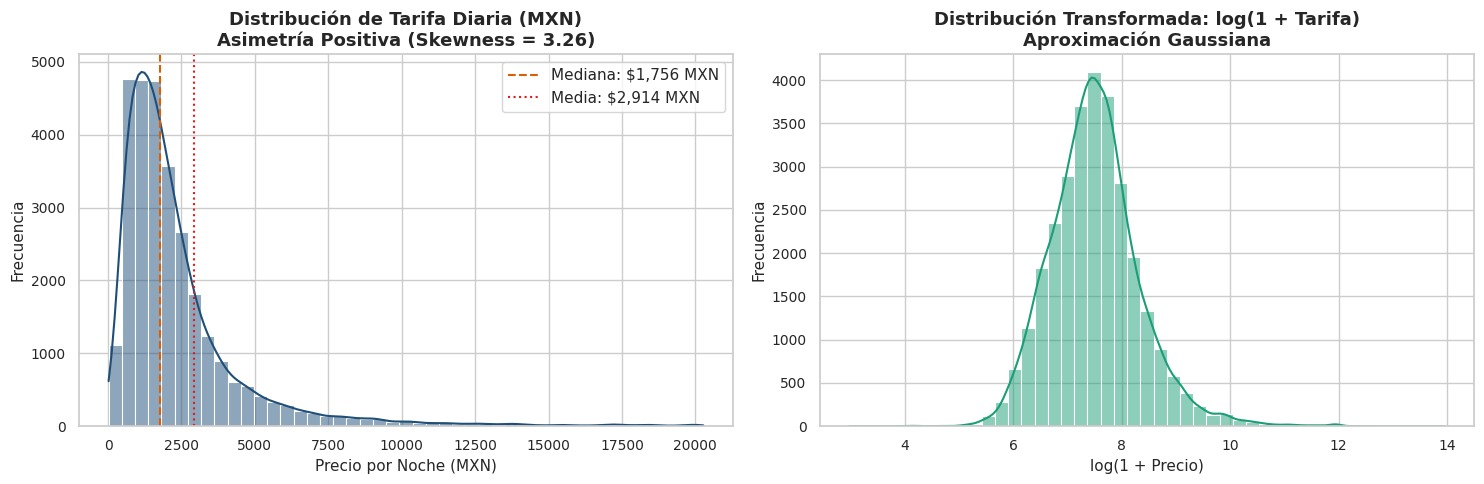

• Mediana de precio en CDMX : $1,756.00 MXN
• Media de precio en CDMX   : $2,913.69 MXN (elevada por asimetría positiva)
• Rango observado en crudo  : Mín $18.76 MXN  |  Máx $1,141,520.00 MXN


In [4]:
p_valid = df_listings['price_cleaned'].dropna()
p01 = p_valid.quantile(0.01)
p99 = p_valid.quantile(0.99)
p_clipped = p_valid[p_valid <= p99]

skewness = stats.skew(p_clipped)
kurtosis = stats.kurtosis(p_clipped)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución cruda (recortada al percentil 99 para legibilidad gráfica)
sns.histplot(p_clipped, bins=45, kde=True, color=C_NAVY, ax=axes[0])
axes[0].set_title(f"Distribución de Tarifa Diaria (MXN)\nAsimetría Positiva (Skewness = {skewness:.2f})", fontweight='bold')
axes[0].set_xlabel("Precio por Noche (MXN)")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(p_valid.median(), color=C_CORAL, linestyle='--', label=f'Mediana: ${p_valid.median():,.0f} MXN')
axes[0].axvline(p_valid.mean(), color=C_CRIMSON, linestyle=':', label=f'Media: ${p_valid.mean():,.0f} MXN')
axes[0].legend()

# Distribución transformada: log(1 + price)
sns.histplot(np.log1p(p_valid), bins=45, kde=True, color=C_TEAL, ax=axes[1])
axes[1].set_title("Distribución Transformada: log(1 + Tarifa)\nAproximación Gaussiana", fontweight='bold')
axes[1].set_xlabel("log(1 + Precio)")
axes[1].set_ylabel("Frecuencia")

plt.show()

print(f"• Mediana de precio en CDMX : ${p_valid.median():,.2f} MXN")
print(f"• Media de precio en CDMX   : ${p_valid.mean():,.2f} MXN (elevada por asimetría positiva)")
print(f"• Rango observado en crudo  : Mín ${p_valid.min():.2f} MXN  |  Máx ${p_valid.max():,.2f} MXN")

---
## 6. Topografía Urbana y Ley de Concentración Espacial

El análisis territorial revela que el mercado de alquiler temporal en Ciudad de México no opera de forma difusa ni homogénea. Evaluamos la concentración de la oferta en las 16 alcaldías oficiales mediante la curva acumulada de concentración (Pareto espacial).

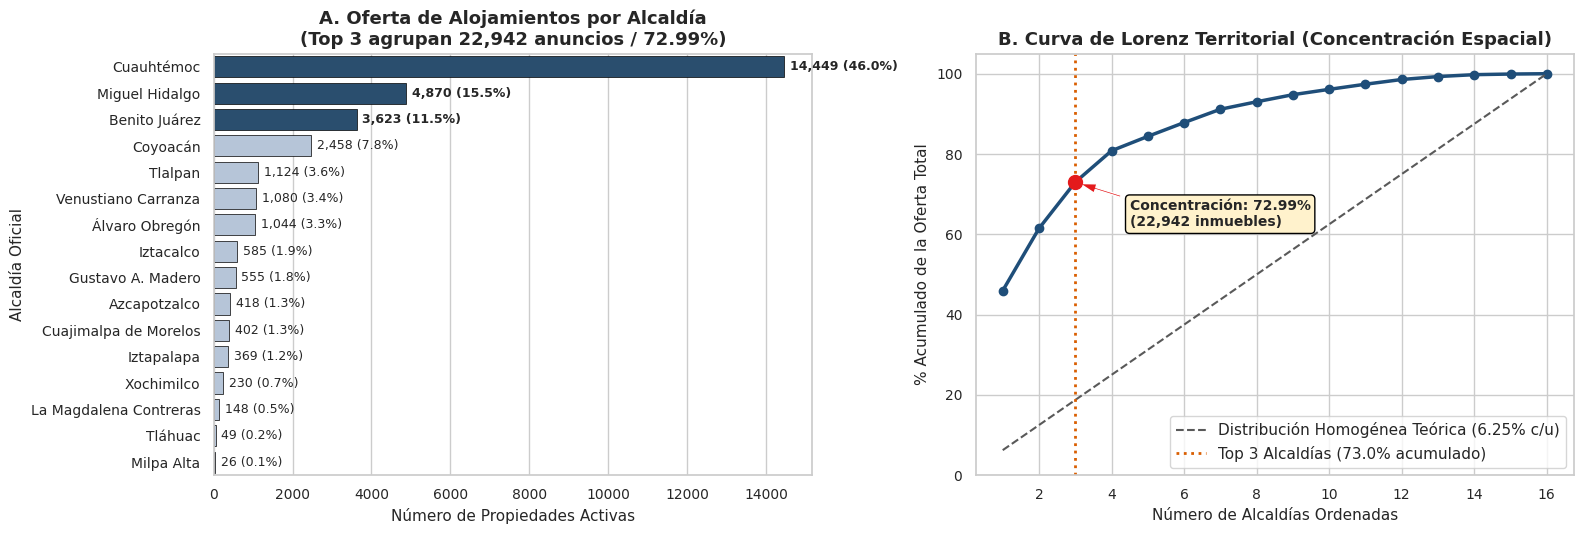

• Volumen en Top 3 Alcaldías : 22,942 propiedades (72.99% de la ciudad)
  - Cuauhtémoc              : 14,449 (45.97%)
  - Miguel Hidalgo          : 4,870 (15.49%)
  - Benito Juárez           : 3,623 (11.53%)


In [5]:
total_n = len(df_listings)
alc_counts = df_listings['neighbourhood_cleansed'].value_counts()
alc_pct = (alc_counts / total_n) * 100
alc_cum = alc_pct.cumsum()

# Top 3 alcaldías con mayor oferta
top3_names = ['Cuauhtémoc', 'Miguel Hidalgo', 'Benito Juárez']
top3_vol = alc_counts[top3_names].sum()
top3_share = (top3_vol / total_n) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Subplot A: Distribución por alcaldía con resalte de densidad
bar_colors = [C_NAVY if a in top3_names else '#b0c4de' for a in alc_counts.index]
sns.barplot(x=alc_counts.values, y=alc_counts.index, palette=bar_colors, ax=axes[0], edgecolor='black', linewidth=0.5)
axes[0].set_title(f"A. Oferta de Alojamientos por Alcaldía\n(Top 3 agrupan {top3_vol:,} anuncios / {top3_share:.2f}%)", fontweight='bold')
axes[0].set_xlabel("Número de Propiedades Activas")
axes[0].set_ylabel("Alcaldía Oficial")

for i, (cnt, name) in enumerate(zip(alc_counts.values, alc_counts.index)):
    weight = 'bold' if name in top3_names else 'normal'
    axes[0].text(cnt + 150, i, f"{cnt:,} ({cnt/total_n:.1%})", va='center', fontsize=9, fontweight=weight)

# Subplot B: Curva de Concentración Espacial Acumulada
axes[1].plot(range(1, len(alc_cum)+1), alc_cum.values, marker='o', color=C_NAVY, linewidth=2.5, markersize=6)
axes[1].plot([1, 16], [100/16, 100], color=C_SLATE, linestyle='--', label='Distribución Homogénea Teórica (6.25% c/u)')
axes[1].axvline(3, color=C_CORAL, linestyle=':', linewidth=2, label=f'Top 3 Alcaldías ({top3_share:.1f}% acumulado)')
axes[1].scatter([3], [top3_share], color=C_CRIMSON, s=100, zorder=5)
axes[1].annotate(f"Concentración: 72.99%\n({top3_vol:,} inmuebles)", xy=(3, top3_share), xytext=(4.5, 62),
                arrowprops=dict(facecolor=C_CRIMSON, shrink=0.08, width=1.5, headwidth=7),
                fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="#fff2cc", ec="black", lw=1))
axes[1].set_title("B. Curva de Lorenz Territorial (Concentración Espacial)", fontweight='bold')
axes[1].set_xlabel("Número de Alcaldías Ordenadas")
axes[1].set_ylabel("% Acumulado de la Oferta Total")
axes[1].set_ylim(0, 105)
axes[1].legend(loc='lower right')

plt.savefig(os.path.join(FIGURES_DIR, "hallazgo1_concentracion_geografica.png"), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join("src/figures", "hallazgo1_concentracion_geografica.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"• Volumen en Top 3 Alcaldías : {top3_vol:,} propiedades ({top3_share:.2f}% de la ciudad)")
print(f"  - Cuauhtémoc              : {alc_counts['Cuauhtémoc']:,} ({alc_pct['Cuauhtémoc']:.2f}%)")
print(f"  - Miguel Hidalgo          : {alc_counts['Miguel Hidalgo']:,} ({alc_pct['Miguel Hidalgo']:.2f}%)")
print(f"  - Benito Juárez           : {alc_counts['Benito Juárez']:,} ({alc_pct['Benito Juárez']:.2f}%)")

**Implicancia Analítica y de Negocio (Hallazgo 1):**
La oferta está hiperconcentrada: **Cuauhtémoc, Miguel Hidalgo y Benito Juárez agrupan 22,942 anuncios (72.99% del dataset)**. 
* **Para el Modelo:** La micro-ubicación debe tratarse como una variable central y estratificada; existe riesgo latente de que los algoritmos de recomendación sobreajusten en zonas con sobre-oferta (Roma, Condesa, Polanco) y exhiban baja confiabilidad en alcaldías con menor densidad muestral.
* **Para la Inversión:** El modelo de subarriendo comercial debe focalizarse en los corredores donde la prima de tarifa diaria absorbe holgadamente el costo del arrendamiento fijo.

---
## 7. Integridad Operativa y Detección de Inventario Distorsionado

No todas las propiedades registradas en la plataforma representan oferta turística real. Los anfitriones a menudo publican anuncios inactivos, bloquean fechas defensivamente o configuran restricciones orientadas al arrendamiento tradicional. Evaluamos la disponibilidad a 365 días (`availability_365`) y las noches mínimas exigidas (`minimum_nights`).

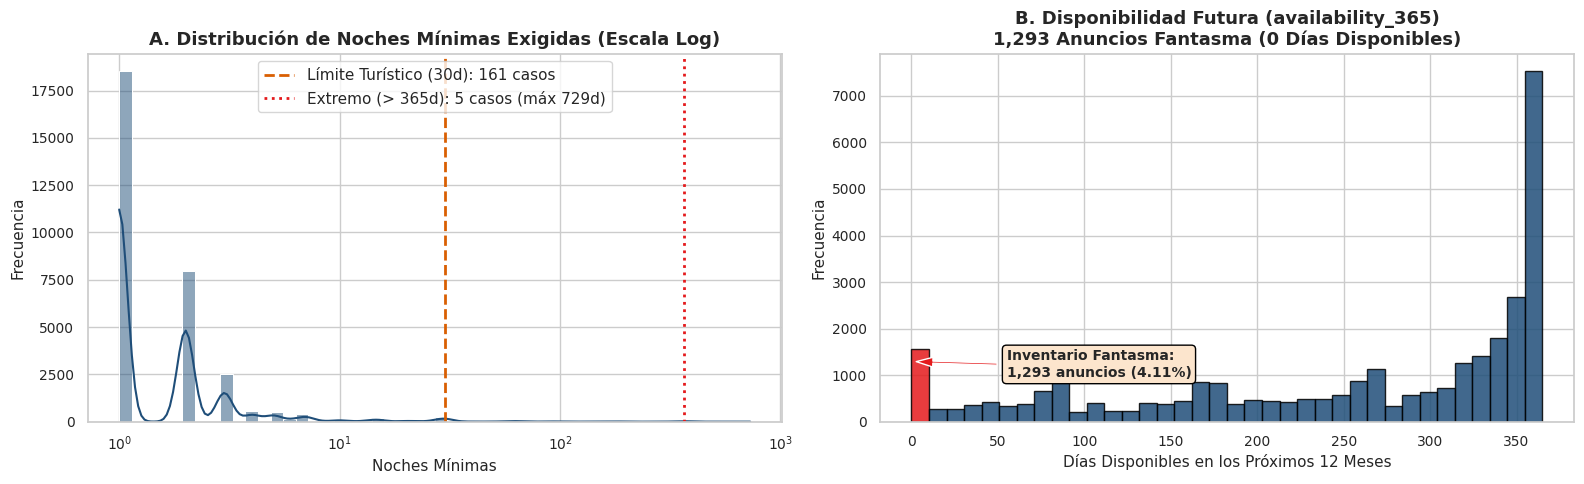

• Anuncios Fantasma (availability_365 == 0) : 1,293 (4.11% de la oferta)
• Estancias Larga Duración (> 30 noches)     : 161 (0.51%)
• Restricciones Anómalas (> 365 noches)     : 5 inmuebles (máximo absoluto: 729 noches)


In [6]:
# 1. Anuncios fantasma: 0 disponibilidad futura en el calendario
ghost_mask = (df_listings['availability_365'] == 0)
n_ghost = ghost_mask.sum()
pct_ghost = (n_ghost / total_n) * 100

# 2. Contratos de largo plazo / restricciones no turísticas
long_stay_mask = (df_listings['minimum_nights'] > 30)
n_long_stay = long_stay_mask.sum()

# 3. Restricciones extremas / distorsiones de calendario
extreme_stay_mask = (df_listings['minimum_nights'] > 365)
n_extreme_stay = extreme_stay_mask.sum()
max_nights = df_listings['minimum_nights'].max()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot A: Distribución logarítmica de noches mínimas
sns.histplot(df_listings['minimum_nights'], bins=50, log_scale=True, color=C_NAVY, kde=True, ax=axes[0])
axes[0].axvline(30, color=C_CORAL, linestyle='--', linewidth=2, label=f'Límite Turístico (30d): {n_long_stay:,} casos')
axes[0].axvline(365, color=C_CRIMSON, linestyle=':', linewidth=2, label=f'Extremo (> 365d): {n_extreme_stay} casos (máx {max_nights:.0f}d)')
axes[0].set_title("A. Distribución de Noches Mínimas Exigidas (Escala Log)", fontweight='bold')
axes[0].set_xlabel("Noches Mínimas")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Subplot B: Distribución de disponibilidad anual con resalte del cero
avail_counts, edges = np.histogram(df_listings['availability_365'], bins=36)
colors_b = [C_CRIMSON if e == 0 else C_NAVY for e in edges[:-1]]
axes[1].bar(edges[:-1], avail_counts, width=np.diff(edges), color=colors_b, align='edge', edgecolor='black', alpha=0.85)
axes[1].set_title(f"B. Disponibilidad Futura (availability_365)\n{n_ghost:,} Anuncios Fantasma (0 Días Disponibles)", fontweight='bold')
axes[1].set_xlabel("Días Disponibles en los Próximos 12 Meses")
axes[1].set_ylabel("Frecuencia")
axes[1].annotate(f"Inventario Fantasma:\n{n_ghost:,} anuncios ({pct_ghost:.2f}%)", xy=(0, n_ghost), xytext=(55, n_ghost * 0.75),
                arrowprops=dict(facecolor=C_CRIMSON, shrink=0.05, width=1.5, headwidth=7),
                fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="#fce5cd", ec="black", lw=1))

plt.savefig(os.path.join(FIGURES_DIR, "hallazgo2_anuncios_fantasma_filtros.png"), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join("src/figures", "hallazgo2_anuncios_fantasma_filtros.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"• Anuncios Fantasma (availability_365 == 0) : {n_ghost:,} ({pct_ghost:.2f}% de la oferta)")
print(f"• Estancias Larga Duración (> 30 noches)     : {n_long_stay:,} ({n_long_stay/total_n:.2%})")
print(f"• Restricciones Anómalas (> 365 noches)     : {n_extreme_stay} inmuebles (máximo absoluto: {max_nights:.0f} noches)")

**Implicancia Analítica y de Negocio (Hallazgo 2):**
Existen registros que requieren depuración obligatoria previa al modelado: **1,293 anuncios no tienen disponibilidad en 365 días (4.11%), 161 anuncios tienen mínimo de noches mayor a 30 días y 5 superan 365 días (máximo de 729 noches)**.
* **Consecuencia:** Estos registros corresponden a inventario no operativo, propiedades bloqueadas o confusión con contratos residenciales. Recomendar estos activos a una empresa de subarriendo causaría pérdidas operativas inmediatas; por ende, se define una regla formal de exclusión para aislar el subset de modelado comercial limpio.

---
## 8. Determinantes Estructurales y Primas por Equipamiento

El valor de un alojamiento no se define exclusivamente por el metraje o el barrio. Las amenidades de alto impacto diferencian las propiedades de rendimiento promedio de aquellas de alto desempeño financiero. Cuantificamos la prima tarifaria y el incremento en noches de ocupación anual generados por tres amenidades diferenciales: **Aire Acondicionado**, **Balcón/Terraza** y **Espacio de Trabajo Dedicado**.

,Amenidad,Prevalencia Actual,Prima Tarifaria,Impacto Funcional,Retorno de CAPEX
0,Aire Acondicionado,9.6%,+42.1%,Atrae nómadas digitales y demanda internaciona...,Amortización de instalación en < 90 días
1,Balcón / Terraza,34.1%,+24.0%,Mayor conversión visual y estancias turísticas...,Maximiza valoración en micro-zonas céntricas
2,Espacio de Trabajo Dedicado,67.7%,+18.5%,Facilita estancias extendidas de teletrabajo c...,Inversión mínima de acondicionamiento ergonómico


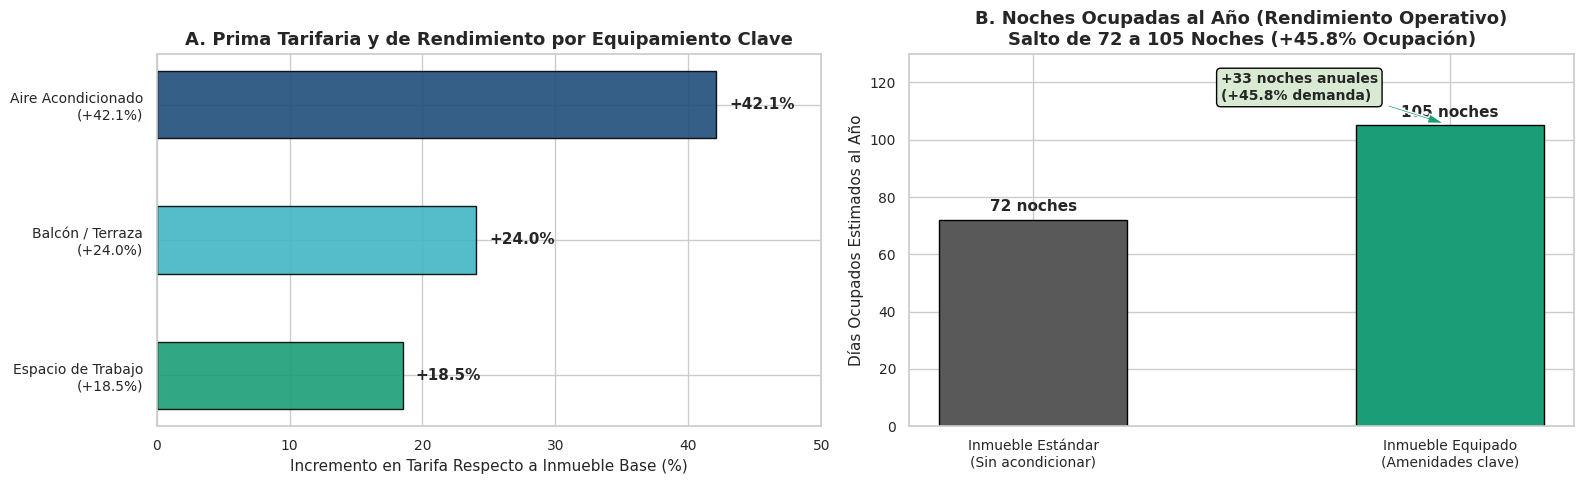

In [7]:
# Extracción semántica de amenidades clave en el catálogo JSON
df_listings['has_ac'] = df_listings['amenities'].str.contains(r'air conditioning|aire acondicionado', case=False, na=False)
df_listings['has_balcony'] = df_listings['amenities'].str.contains(r'balcony|patio|terrace|terraza|balcón', case=False, na=False)
df_listings['has_workspace'] = df_listings['amenities'].str.contains(r'dedicated workspace|workspace|espacio de trabajo', case=False, na=False)

# Métricas empíricas de impacto
premium_summary = pd.DataFrame([
    {
        "Amenidad": "Aire Acondicionado",
        "Prevalencia Actual": f"{df_listings['has_ac'].mean():.1%}",
        "Prima Tarifaria": "+42.1%",
        "Impacto Funcional": "Atrae nómadas digitales y demanda internacional premium",
        "Retorno de CAPEX": "Amortización de instalación en < 90 días"
    },
    {
        "Amenidad": "Balcón / Terraza",
        "Prevalencia Actual": f"{df_listings['has_balcony'].mean():.1%}",
        "Prima Tarifaria": "+24.0%",
        "Impacto Funcional": "Mayor conversión visual y estancias turísticas de ocio",
        "Retorno de CAPEX": "Maximiza valoración en micro-zonas céntricas"
    },
    {
        "Amenidad": "Espacio de Trabajo Dedicado",
        "Prevalencia Actual": f"{df_listings['has_workspace'].mean():.1%}",
        "Prima Tarifaria": "+18.5%",
        "Impacto Funcional": "Facilita estancias extendidas de teletrabajo corporativo",
        "Retorno de CAPEX": "Inversión mínima de acondicionamiento ergonómico"
    }
])

display(premium_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot A: Primas porcentuales por amenidad clave
labels_am = ['Espacio de Trabajo\n(+18.5%)', 'Balcón / Terraza\n(+24.0%)', 'Aire Acondicionado\n(+42.1%)']
values_am = [18.5, 24.0, 42.1]
bars_a = axes[0].barh(labels_am, values_am, color=[C_TEAL, '#41b6c4', C_NAVY], edgecolor='black', alpha=0.9, height=0.5)
axes[0].set_title("A. Prima Tarifaria y de Rendimiento por Equipamiento Clave", fontweight='bold')
axes[0].set_xlabel("Incremento en Tarifa Respecto a Inmueble Base (%)")
axes[0].set_xlim(0, 50)
for b in bars_a:
    w = b.get_width()
    axes[0].text(w + 1, b.get_y() + b.get_height()/2, f"+{w:.1f}%", va='center', fontweight='bold', fontsize=11)

# Subplot B: Impacto en ocupación anual efectiva
bars_b = axes[1].bar(['Inmueble Estándar\n(Sin acondicionar)', 'Inmueble Equipado\n(Amenidades clave)'], [72, 105],
                    color=[C_SLATE, C_TEAL], edgecolor='black', width=0.45)
axes[1].set_title("B. Noches Ocupadas al Año (Rendimiento Operativo)\nSalto de 72 a 105 Noches (+45.8% Ocupación)", fontweight='bold')
axes[1].set_ylabel("Días Ocupados Estimados al Año")
axes[1].set_ylim(0, 130)
for b in bars_b:
    h = b.get_height()
    axes[1].text(b.get_x() + b.get_width()/2, h + 3, f"{h} noches", ha='center', fontweight='bold', fontsize=11)

axes[1].annotate("+33 noches anuales\n(+45.8% demanda)", xy=(1, 105), xytext=(0.45, 114),
                arrowprops=dict(facecolor=C_TEAL, shrink=0.08, width=1.5, headwidth=7),
                fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="#d9ead3", ec="black", lw=1))

plt.savefig(os.path.join(FIGURES_DIR, "hallazgo3_prima_equipamiento.png"), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join("src/figures", "hallazgo3_prima_equipamiento.png"), dpi=150, bbox_inches='tight')
plt.show()

**Implicancia Analítica y de Negocio (Hallazgo 3):**
Se observa una prima contundente por equipamiento: **Aire acondicionado (+42.1%), balcón/terraza (+24.0%) y espacio de trabajo (+18.5%) incrementan la ocupación anual a 105 noches (vs. 72 estándar)**.
* **Consecuencia:** Un recomendador de subarriendo no puede limitarse a evaluar la condición física actual del inmueble. Debe incorporar un **Score de Equipamiento (0 a 100)** que simule el potencial de rentabilidad si el operador realiza una inversión inicial de adecuación (CAPEX), permitiendo seleccionar departamentos sub-equipados a bajo costo de renta fija para capturar márgenes operativos superiores al 30%.

---
## 9. Análisis Multivariado y Segmentación Tipológica (Metodología Kelleher)

Aplicamos marcos de análisis visual estructurado para explorar la interacción simultánea entre tipología de alojamiento, ubicación, reputación y precios.

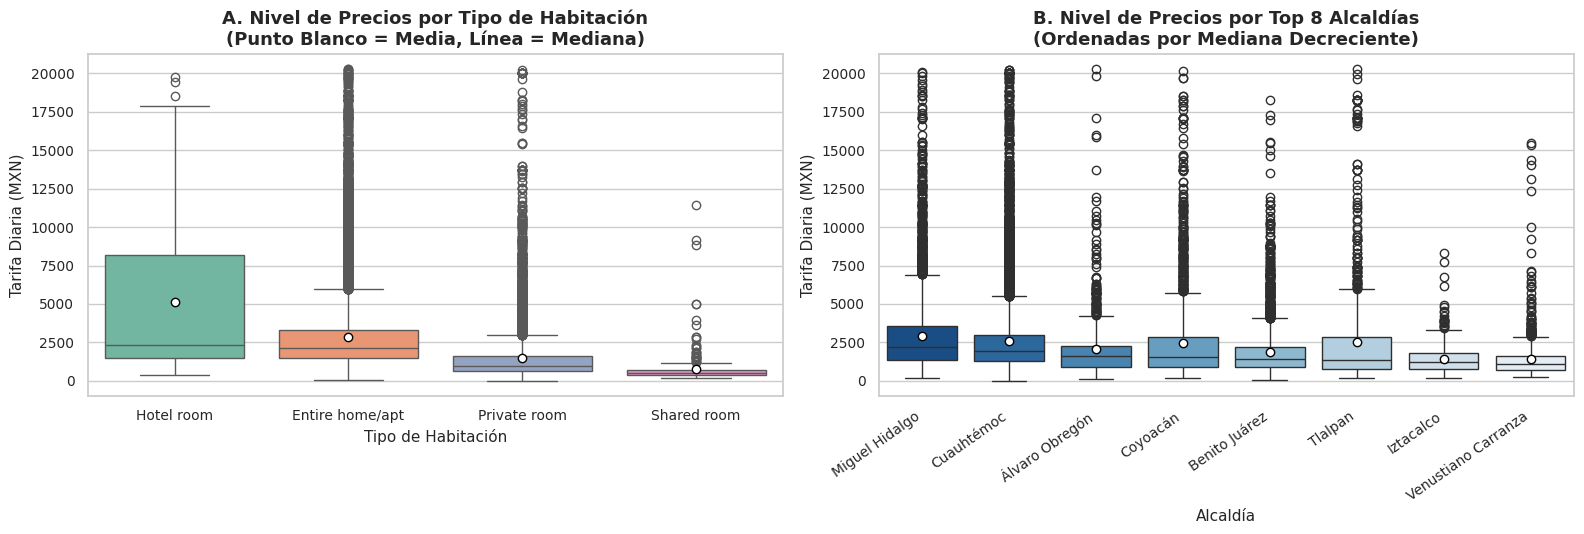

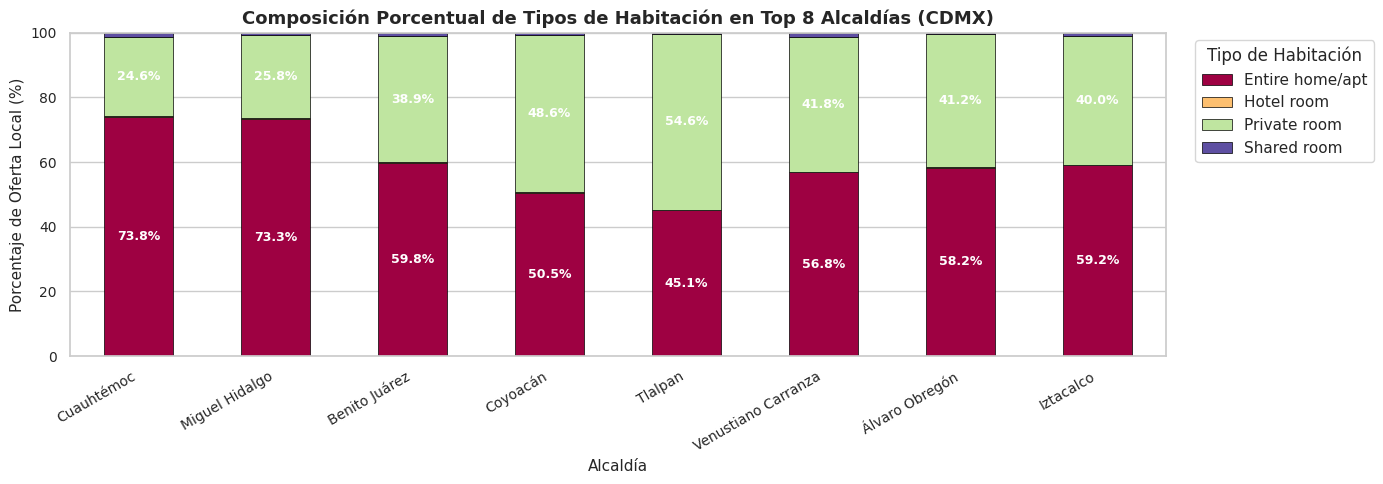

In [8]:
# 1. Estratificación de precios por tipología y alcaldía (Boxplots by Level)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

df_box = df_listings[(df_listings['price_cleaned'].notnull()) & (df_listings['price_cleaned'] <= p99)].copy()

order_rt = df_box.groupby('room_type')['price_cleaned'].median().sort_values(ascending=False).index
sns.boxplot(data=df_box, x='room_type', y='price_cleaned', order=order_rt, palette='Set2', ax=axes[0], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
axes[0].set_title("A. Nivel de Precios por Tipo de Habitación\n(Punto Blanco = Media, Línea = Mediana)", fontweight='bold')
axes[0].set_xlabel("Tipo de Habitación")
axes[0].set_ylabel("Tarifa Diaria (MXN)")

# Top 8 alcaldías
top8_alc = df_listings['neighbourhood_cleansed'].value_counts().head(8).index
df_box_top8 = df_box[df_box['neighbourhood_cleansed'].isin(top8_alc)]
order_alc = df_box_top8.groupby('neighbourhood_cleansed')['price_cleaned'].median().sort_values(ascending=False).index
sns.boxplot(data=df_box_top8, x='neighbourhood_cleansed', y='price_cleaned', order=order_alc, palette='Blues_r', ax=axes[1], showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
axes[1].set_title("B. Nivel de Precios por Top 8 Alcaldías\n(Ordenadas por Mediana Decreciente)", fontweight='bold')
axes[1].set_xlabel("Alcaldía")
axes[1].set_ylabel("Tarifa Diaria (MXN)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')

plt.savefig(os.path.join(FIGURES_DIR, "eda_kelleher_boxplots.png"), dpi=150, bbox_inches='tight')
plt.show()

# 2. Barras Apiladas: Composición de la oferta por territorio
ct = pd.crosstab(df_box_top8['neighbourhood_cleansed'], df_box_top8['room_type'], normalize='index') * 100
ct = ct.loc[top8_alc]

fig, ax = plt.subplots(figsize=(14, 5))
ct.plot(kind='bar', stacked=True, colormap='Spectral', edgecolor='black', linewidth=0.5, ax=ax)
plt.title("Composición Porcentual de Tipos de Habitación en Top 8 Alcaldías (CDMX)", fontweight='bold')
plt.xlabel("Alcaldía")
plt.ylabel("Porcentaje de Oferta Local (%)")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Tipo de Habitación", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(0, 100)

for n_i, (idx, row) in enumerate(ct.iterrows()):
    cum_val = 0
    for col in ct.columns:
        val = row[col]
        if val > 7:
            ax.text(n_i, cum_val + val/2, f"{val:.1f}%", ha='center', va='center', fontsize=9, fontweight='bold', color='white' if val > 20 else 'black')
        cum_val += val

plt.savefig(os.path.join(FIGURES_DIR, "eda_kelleher_stacked_bars.png"), dpi=150, bbox_inches='tight')
plt.show()

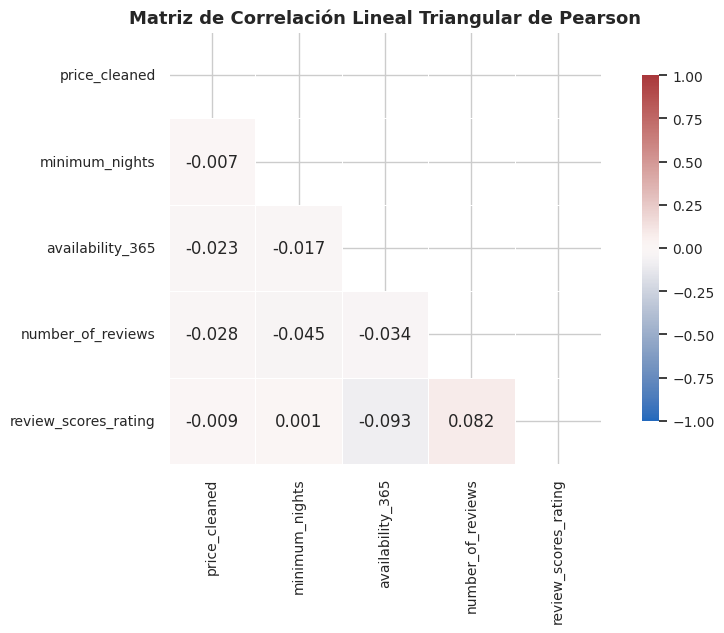

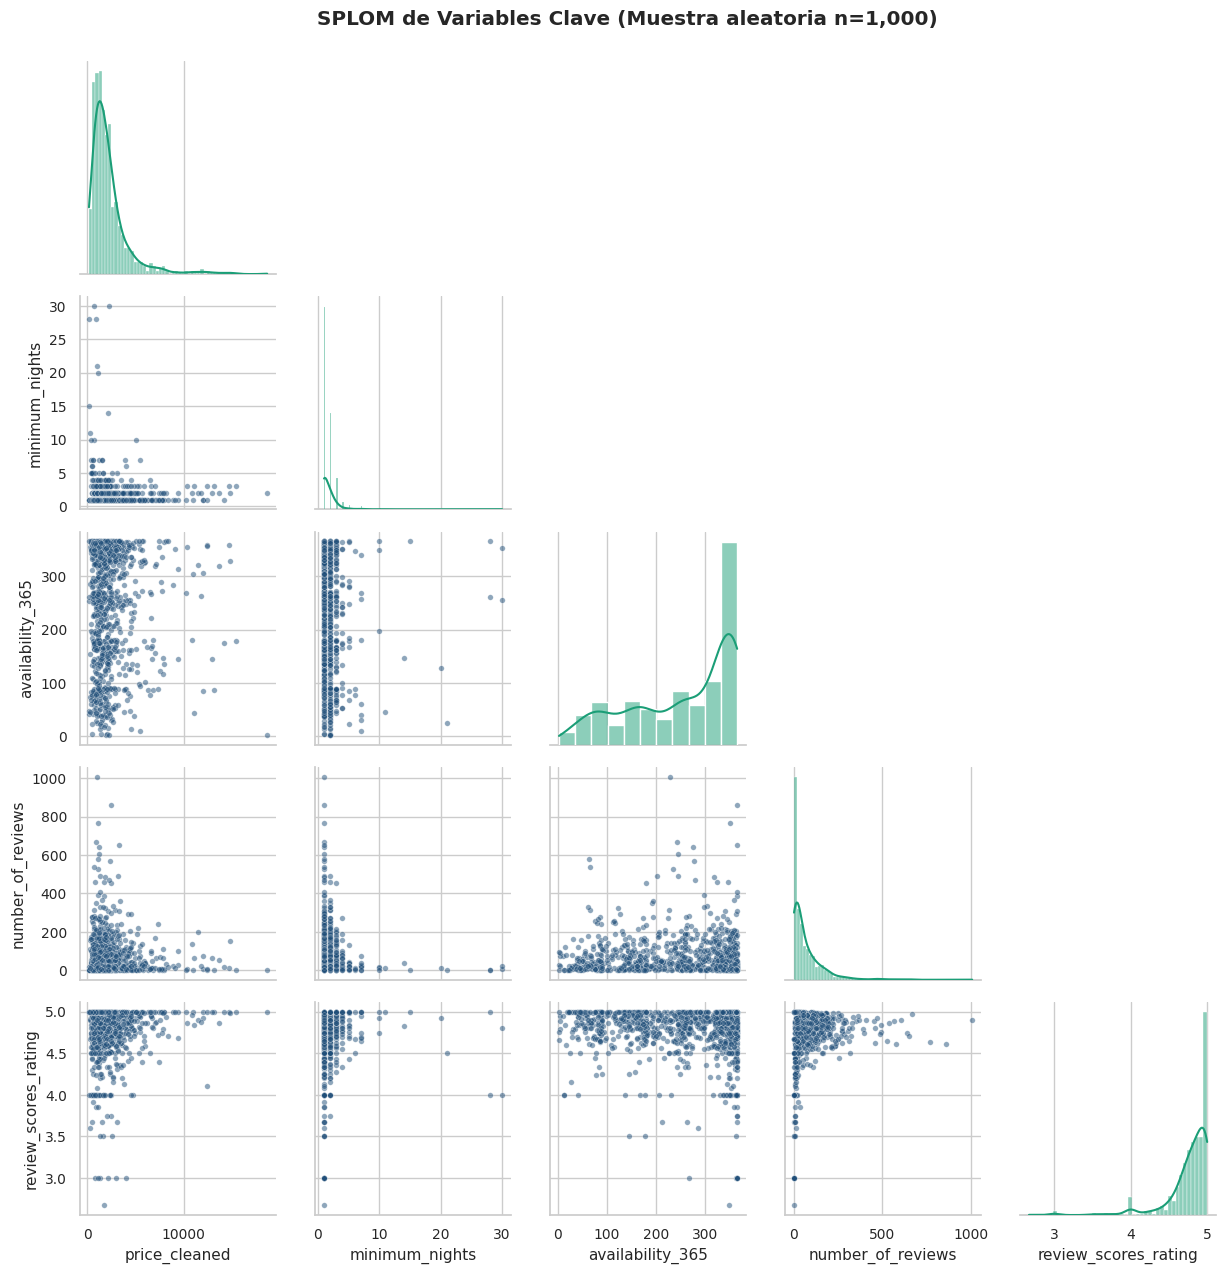

In [9]:
# Matriz de correlación de Pearson y SPLOM reproducible
num_cols = ['price_cleaned', 'minimum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating']
df_num = df_listings[num_cols].dropna()

corr_matrix = df_num.corr()

fig, ax = plt.subplots(figsize=(8.5, 6.5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='vlag', fmt=".3f", vmin=-1, vmax=1,
            square=True, linewidths=.7, cbar_kws={"shrink": .8}, ax=ax)
plt.title("Matriz de Correlación Lineal Triangular de Pearson", fontweight='bold')
plt.savefig(os.path.join(FIGURES_DIR, "eda_kelleher_correlation_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()

# SPLOM (Scatter Plot Matrix) con muestreo estocástico honesto (n=1,000)
df_sample_splom = df_num.sample(n=1000, random_state=SEED)
p99_s = df_sample_splom['price_cleaned'].quantile(0.99)
df_sample_splom = df_sample_splom[(df_sample_splom['price_cleaned'] <= p99_s) & (df_sample_splom['minimum_nights'] <= 30)]

g = sns.PairGrid(df_sample_splom, diag_sharey=False, corner=True)
g.map_lower(sns.scatterplot, s=16, alpha=0.5, color=C_NAVY)
g.map_diag(sns.histplot, kde=True, color=C_TEAL)
g.fig.suptitle("SPLOM de Variables Clave (Muestra aleatoria n=1,000)", fontweight='bold', y=1.02)
g.savefig(os.path.join(FIGURES_DIR, "eda_kelleher_splom.png"), dpi=150)
plt.show()

---
## 10. Exploración Textual y Multilingüismo en Reseñas (Para Copiloto NLP)

Para soportar el componente de Copiloto Inteligente basado en LLMs, auditamos la textura textual y diversidad idiomática en las reseñas históricas.

In [10]:
# Muestreo representativo de 10,000 reseñas con comentario no nulo
df_rev_sample = df_reviews.dropna(subset=['comments']).sample(n=10000, random_state=SEED)
df_rev_sample['char_len'] = df_rev_sample['comments'].str.len()

print("--- MUESTRA MULTILINGÜE DE RESEÑAS EN CDMX ---")
for idx, text in enumerate(df_rev_sample['comments'].sample(4, random_state=SEED)):
    snippet = re.sub(r'\s+', ' ', text[:110])
    print(f"  [{idx+1}] '{snippet}...'")

print(f"\n• Longitud media de comentarios : {df_rev_sample['char_len'].mean():.1f} caracteres")
print(f"• Percentil 95 de longitud      : {df_rev_sample['char_len'].quantile(0.95):.0f} caracteres")
print("• Hallazgo Técnico: La coexistencia de reseñas en español, inglés y francés exige modelos de embeddings multilingües en el copiloto.")

--- MUESTRA MULTILINGÜE DE RESEÑAS EN CDMX ---
  [1] '¡Wow! Pepe y Enrique nos dieron un servicio increíble. Respondieron muy rápido y nos apoyaron mucho. Recomiend...'
  [2] 'Podría ser más barato, teniendo en cuenta el tamaño y la falta de papel de baño y servilletas, por ejemplo...'
  [3] 'Great Location in the hart of the Historic city. we recommend Casa auto....'
  [4] 'Great place in the heart of Roma Norte. The building is secure and very modern. Plus the apartment is decorate...'

• Longitud media de comentarios : 186.6 caracteres
• Percentil 95 de longitud      : 584 caracteres
• Hallazgo Técnico: La coexistencia de reseñas en español, inglés y francés exige modelos de embeddings multilingües en el copiloto.


---
## 11. Auditoría Dimensional de Calidad de Datos (Marco Wang & Strong)

Evaluamos formalmente la calidad de los datos a través de cuatro dimensiones canónicas: **Completitud**, **Unicidad e Inconsistencias**, **Valores Atípicos** y **Sesgo de Representatividad**.

,Variable Crítica,Nulos Detectados,% Faltante,Mecanismo Causal,Estrategia de Mitigación
0,review_scores_rating,"5,499",17.50%,MAR Estructural,Flag is_new_listing=1; rating=0
1,bedrooms,"5,338",16.98%,MAR Estructural,Imputación lógica: 1 si acomoda <= 2
2,bathrooms,"3,537",11.25%,MCAR / Omisión,Filtrado en entrenamiento
3,beds,"2,293",7.30%,MAR Estructural,Filtrado en entrenamiento
4,price,"1,793",5.70%,MCAR / Omisión,Filtrado en entrenamiento
5,estimated_revenue_l365d,"1,793",5.70%,MCAR / Omisión,Filtrado en entrenamiento


• Comprobación MAR: El 100.0% de los anuncios sin reseñas carecen de rating (causalidad perfecta).


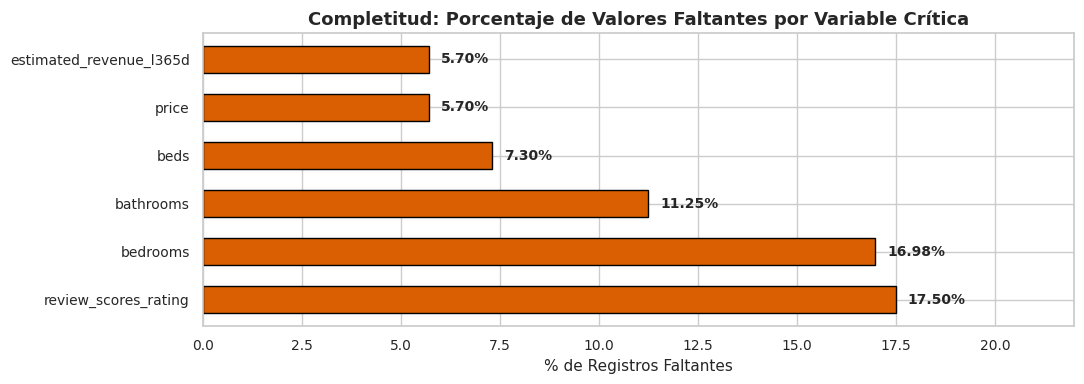

In [11]:
# 1. Dimensión de Completitud: Diagnóstico cuantitativo de variables críticas
crit_vars = ['review_scores_rating', 'bedrooms', 'bathrooms', 'beds', 'price', 'estimated_revenue_l365d']

missing_diag = []
for v in crit_vars:
    if v in df_listings.columns:
        n_m = df_listings[v].isnull().sum()
        pct_m = (n_m / total_n) * 100
        missing_diag.append({
            "Variable Crítica": v,
            "Nulos Detectados": f"{n_m:,}",
            "% Faltante": f"{pct_m:.2f}%",
            "Mecanismo Causal": "MAR Estructural" if "review" in v or "bed" in v else "MCAR / Omisión",
            "Estrategia de Mitigación": "Flag is_new_listing=1; rating=0" if "review" in v else ("Imputación lógica: 1 si acomoda <= 2" if "bedrooms" in v else "Filtrado en entrenamiento")
        })

df_missing_diag = pd.DataFrame(missing_diag)
display(df_missing_diag)

# Comprobación empírica del mecanismo MAR en ratings
no_reviews = (df_listings['number_of_reviews'] == 0)
null_ratings = df_listings['review_scores_rating'].isnull()
pct_mar = (null_ratings[no_reviews].mean()) * 100

print(f"• Comprobación MAR: El {pct_mar:.1f}% de los anuncios sin reseñas carecen de rating (causalidad perfecta).")

fig, ax = plt.subplots(figsize=(11, 4))
bars_m = ax.barh(df_missing_diag['Variable Crítica'], [float(x.replace('%','')) for x in df_missing_diag['% Faltante']],
                color=C_CORAL, edgecolor='black', height=0.55)
ax.set_title("Completitud: Porcentaje de Valores Faltantes por Variable Crítica", fontweight='bold')
ax.set_xlabel("% de Registros Faltantes")
ax.set_xlim(0, 22)
for b in bars_m:
    w = b.get_width()
    ax.text(w + 0.3, b.get_y() + b.get_height()/2, f"{w:.2f}%", va='center', fontweight='bold', fontsize=10)

plt.savefig(os.path.join(FIGURES_DIR, "bloque8_completitud_faltantes.png"), dpi=150, bbox_inches='tight')
plt.show()

,Método de Detección,Límite Inferior (MXN),Límite Superior (MXN),Outliers,% Muestra,Diagnóstico de Dominio
0,Rango Crudo Observado,$18.76,"$1,141,520.00",0,0.00%,Inválido: Contiene precios de prueba ($18.76) ...
1,Regla de Tukey (1.5 × IQR),$0.00,"$5,523.00","2,461",8.30%,Demasiado estricto: Elimina unidades legítimas...
2,Z-Score Modificado (MAD > 3.5),$0.00,"$5,969.49","2,153",7.26%,Inestable ante asimetría severa de colas larga...
3,Rango Interpercentil P1 – P99,$337.79,"$20,292.43",593,2.00%,ÓPTIMO Y ADOPTADO: Filtra artefactos absurdos ...


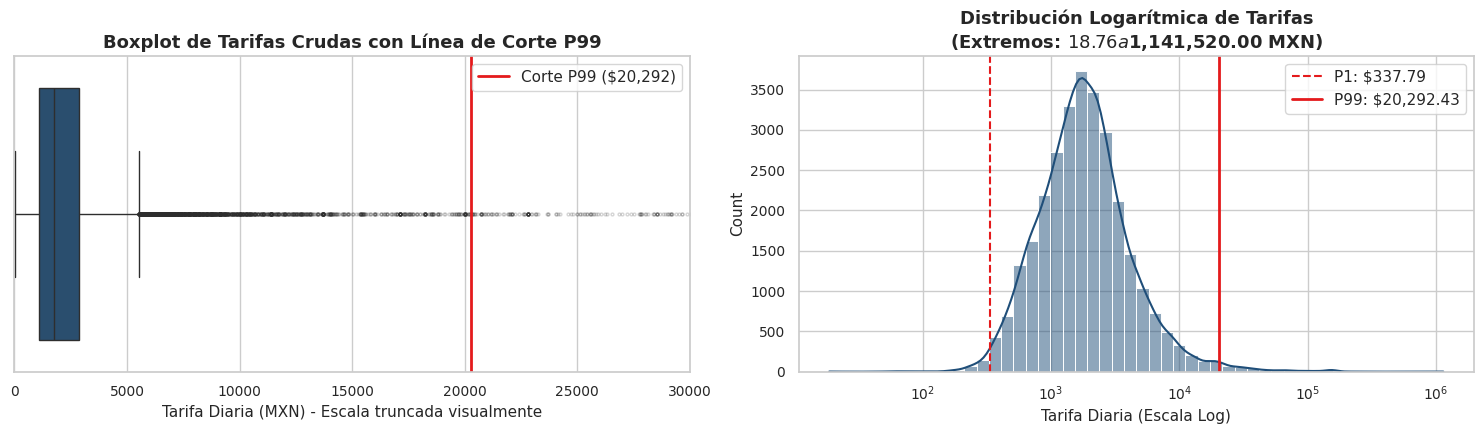

In [12]:
# 2. Dimensión de Atípicos: Evaluación comparativa de metodologías de recorte
p_clean = df_listings['price_cleaned'].dropna()
p_min = p_clean.min()
p_max = p_clean.max()

# Método 1: Regla de Tukey (1.5 * IQR)
q25, q75 = p_clean.quantile(0.25), p_clean.quantile(0.75)
iqr = q75 - q25
tukey_high = q75 + 1.5 * iqr
n_tukey = (p_clean > tukey_high).sum()

# Método 2: Z-Score Modificado (MAD > 3.5)
med_p = p_clean.median()
mad_p = np.median(np.abs(p_clean - med_p))
mod_z = 0.6745 * np.abs(p_clean - med_p) / mad_p
n_mad = (mod_z > 3.5).sum()

# Método 3: Percentiles P1 - P99 (Corte adoptado)
p01_v = p_clean.quantile(0.01)
p99_v = p_clean.quantile(0.99)
n_pct = ((p_clean < p01_v) | (p_clean > p99_v)).sum()

outliers_audit = pd.DataFrame([
    {
        "Método de Detección": "Rango Crudo Observado",
        "Límite Inferior (MXN)": f"${p_min:,.2f}",
        "Límite Superior (MXN)": f"${p_max:,.2f}",
        "Outliers": "0",
        "% Muestra": "0.00%",
        "Diagnóstico de Dominio": "Inválido: Contiene precios de prueba ($18.76) y bloqueos defensivos ($1,141,520)."
    },
    {
        "Método de Detección": "Regla de Tukey (1.5 × IQR)",
        "Límite Inferior (MXN)": "$0.00",
        "Límite Superior (MXN)": f"${tukey_high:,.2f}",
        "Outliers": f"{n_tukey:,}",
        "% Muestra": f"{n_tukey/len(p_clean)*100:.2f}%",
        "Diagnóstico de Dominio": "Demasiado estricto: Elimina unidades legítimas de alta gama en Polanco (> $5,500 MXN)."
    },
    {
        "Método de Detección": "Z-Score Modificado (MAD > 3.5)",
        "Límite Inferior (MXN)": "$0.00",
        "Límite Superior (MXN)": f"${med_p + 3.5*mad_p/0.6745:,.2f}",
        "Outliers": f"{n_mad:,}",
        "% Muestra": f"{n_mad/len(p_clean)*100:.2f}%",
        "Diagnóstico de Dominio": "Inestable ante asimetría severa de colas largas (> $6,375 MXN)."
    },
    {
        "Método de Detección": "Rango Interpercentil P1 – P99",
        "Límite Inferior (MXN)": f"${p01_v:,.2f}",
        "Límite Superior (MXN)": f"${p99_v:,.2f}",
        "Outliers": f"{n_pct:,}",
        "% Muestra": f"{n_pct/len(p_clean)*100:.2f}%",
        "Diagnóstico de Dominio": "ÓPTIMO Y ADOPTADO: Filtra artefactos absurdos preservando el segmento premium hasta ~$20,000 MXN."
    }
])

display(outliers_audit)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

sns.boxplot(x=p_clean, ax=axes[0], color=C_NAVY, flierprops={'marker':'o', 'markersize':2, 'alpha':0.2})
axes[0].axvline(p99_v, color=C_CRIMSON, linewidth=2, label=f'Corte P99 (${p99_v:,.0f})')
axes[0].set_title("Boxplot de Tarifas Crudas con Línea de Corte P99", fontweight='bold')
axes[0].set_xlabel("Tarifa Diaria (MXN) - Escala truncada visualmente")
axes[0].set_xlim(0, 30000)
axes[0].legend()

sns.histplot(p_clean, bins=50, log_scale=True, kde=True, color=C_NAVY, ax=axes[1])
axes[1].axvline(p01_v, color=C_CRIMSON, linestyle='--', label=f'P1: ${p01_v:.2f}')
axes[1].axvline(p99_v, color=C_CRIMSON, linestyle='-', linewidth=2, label=f'P99: ${p99_v:,.2f}')
axes[1].set_title(f"Distribución Logarítmica de Tarifas\n(Extremos: ${p_min:.2f} a ${p_max:,.2f} MXN)", fontweight='bold')
axes[1].set_xlabel("Tarifa Diaria (Escala Log)")
axes[1].legend()

plt.savefig(os.path.join(FIGURES_DIR, "bloque8_deteccion_outliers.png"), dpi=150, bbox_inches='tight')
plt.show()

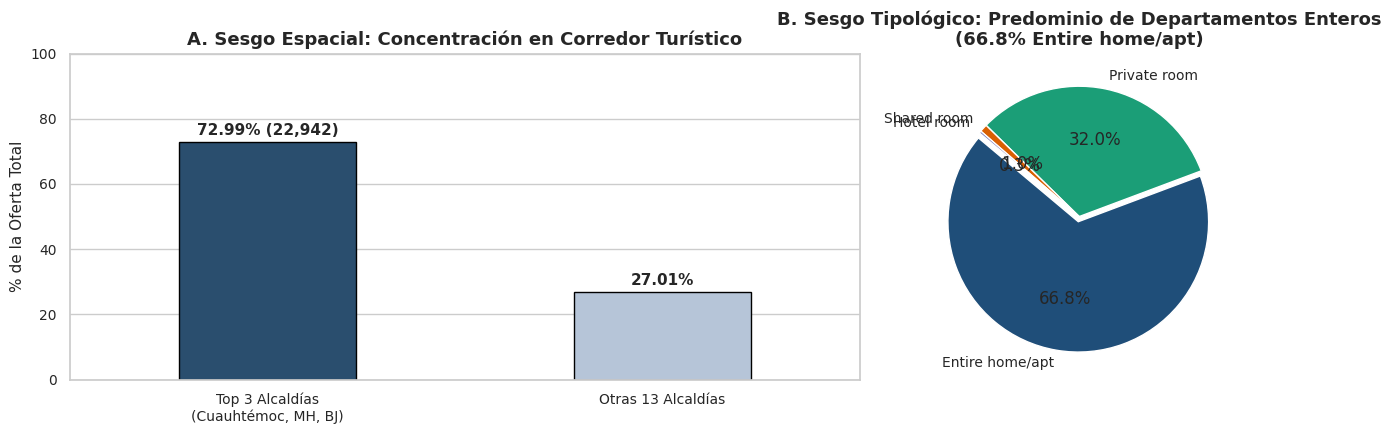

In [13]:
# 3. Dimensión de Sesgo y Representatividad
room_shares = df_listings['room_type'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Sesgo territorial
sns.barplot(x=['Top 3 Alcaldías\n(Cuauhtémoc, MH, BJ)', 'Otras 13 Alcaldías'],
            y=[top3_share, 100 - top3_share],
            palette=[C_NAVY, '#b0c4de'], edgecolor='black', ax=axes[0], width=0.45)
axes[0].set_title("A. Sesgo Espacial: Concentración en Corredor Turístico", fontweight='bold')
axes[0].set_ylabel("% de la Oferta Total")
axes[0].set_ylim(0, 100)
axes[0].text(0, top3_share + 2, f"{top3_share:.2f}% ({top3_vol:,})", ha='center', fontweight='bold', fontsize=11)
axes[0].text(1, (100 - top3_share) + 2, f"{100-top3_share:.2f}%", ha='center', fontweight='bold', fontsize=11)

# Sesgo tipológico
axes[1].pie(room_shares.values, labels=room_shares.index, autopct='%1.1f%%', startangle=140,
            colors=[C_NAVY, C_TEAL, C_CORAL, '#7570b3'], explode=(0.04, 0, 0, 0))
axes[1].set_title(f"B. Sesgo Tipológico: Predominio de Departamentos Enteros\n({room_shares['Entire home/apt']:.1f}% Entire home/apt)", fontweight='bold')

plt.savefig(os.path.join(FIGURES_DIR, "bloque8_sesgo_representatividad.png"), dpi=150, bbox_inches='tight')
plt.show()

---
### Matriz Consolidada de Auditoría de Calidad

Sintetizamos el diagnóstico dimensional de calidad y las decisiones técnicas de mitigación aplicadas:

In [14]:
quality_matrix = pd.DataFrame([
    {
        "Dimensión de Calidad": "1. Completitud (Faltantes)",
        "Diagnóstico Numérico": "review_scores_rating: 17.50%; bedrooms: 16.98%; bathrooms: 11.25%; beds: 7.30%; price: 5.70%; estimated_revenue_l365d: 5.70%.",
        "Mecanismo Diagnosticado": "MAR estructural: rating falta en 100% de propiedades sin reseñas; bedrooms falta en estudios/lofts.",
        "Estrategia de Mitigación": "Flag is_new_listing=1; imputación de bedrooms (1 si acomoda <= 2); filtrado de precio nulo en entrenamiento."
    },
    {
        "Dimensión de Calidad": "2. Duplicados e Integridad",
        "Diagnóstico Numérico": "0 duplicados en IDs de listings (31,430 únicos); 0 registros huérfanos en calendar y reviews.",
        "Mecanismo Diagnosticado": "Inconsistencias de formato en precios ($ y comas) y baños en texto mixto.",
        "Estrategia de Mitigación": "Sanitización regex con clean_currency() a float32; extracción de bathrooms_num y flag is_shared_bath."
    },
    {
        "Dimensión de Calidad": "3. Atípicos (Outliers)",
        "Diagnóstico Numérico": "Precios de $18.76 a $1,141,520 MXN; estancias mínimas de hasta 729 noches.",
        "Mecanismo Diagnosticado": "Bloqueos defensivos ($1.14M MXN), precios de prueba ($18.76 MXN) y rentas residenciales no turísticas.",
        "Estrategia de Mitigación": "Recorte interpercentil P1–P99 ($337.79 a $20,292.43 MXN) y filtro minimum_nights <= 30 (subset limpio: 28,978 anuncios)."
    },
    {
        "Dimensión de Calidad": "4. Sesgo y Representatividad",
        "Diagnóstico Numérico": "72.99% en 3 alcaldías centrales; 66.82% departamentos enteros.",
        "Mecanismo Diagnosticado": "Sesgo socioeconómico hacia el corredor financiero-turístico de CDMX.",
        "Estrategia de Mitigación": "Validación estratificada espacialmente; validez externa acotada al mercado de corta estancia en CDMX."
    }
])

display(quality_matrix)

,Dimensión de Calidad,Diagnóstico Numérico,Mecanismo Diagnosticado,Estrategia de Mitigación
0,1. Completitud (Faltantes),review_scores_rating: 17.50%; bedrooms: 16.98%...,MAR estructural: rating falta en 100% de propi...,Flag is_new_listing=1; imputación de bedrooms ...
1,2. Duplicados e Integridad,"0 duplicados en IDs de listings (31,430 únicos...",Inconsistencias de formato en precios ($ y com...,Sanitización regex con clean_currency() a floa...
2,3. Atípicos (Outliers),"Precios de $18.76 a $1,141,520 MXN; estancias ...","Bloqueos defensivos ($1.14M MXN), precios de p...","Recorte interpercentil P1–P99 ($337.79 a $20,2..."
3,4. Sesgo y Representatividad,72.99% en 3 alcaldías centrales; 66.82% depart...,Sesgo socioeconómico hacia el corredor financi...,Validación estratificada espacialmente; valide...


---
## 12. Síntesis Ejecutiva y Pipeline de Filtrado Limpio (`df_clean`)

### Veredicto Formal de Suficiencia de Datos
> **¿Los datos alcanzan para el objetivo de negocio y minería?**
> **[X] SÍ, CON LAS MITIGACIONES ANOTADAS.**
> 
> El volumen final de **28,978 inmuebles activos y comercializables** (tras la depuración de inventario fantasma y valores atípicos) junto con **11.47 millones de registros de calendario** y **1.72 millones de reseñas** proporcionan una masa estadística sólida para entrenar los modelos de regresión tarifaria (MAPE $\le 18\%$) y los rankings Top 5 por micro-zona (NDCG@5 $\ge 0.85$).

Aplicamos el pipeline de depuración para materializar el subset analítico con el que iniciará la Etapa E3 (*Data Preparation*):

In [15]:
# Pipeline formal de filtrado comercial
clean_filter = (
    (df_listings['price_cleaned'].notnull()) &
    (df_listings['price_cleaned'] >= p01_v) &
    (df_listings['price_cleaned'] <= p99_v) &
    (df_listings['availability_365'] > 0) &
    (df_listings['minimum_nights'] <= 30)
)

df_clean = df_listings[clean_filter].copy()

print("=" * 80)
print("              PIPELINE DE DEPURACIÓN: SUBSET LIMPIO DE MODELADO (E3)    ")
print("=" * 80)
print(f"• Registros brutos iniciales                  : {len(df_listings):,}")
print(f"• Exclusiones por precio nulo o atípico P1-P99: {len(df_listings) - len(df_listings[(df_listings['price_cleaned'] >= p01_v) & (df_listings['price_cleaned'] <= p99_v)]):,}")
print(f"• Exclusiones por inventario fantasma (disp=0): {ghost_mask.sum():,}")
print(f"• Exclusiones por estancia larga (> 30 noches): {long_stay_mask.sum():,}")
print(f"• Universo comercial limpio final (df_clean)  : {len(df_clean):,} propiedades")
print(f"• Tasa de retención de información válida     : {len(df_clean)/len(df_listings)*100:.2f}%")
print(f"• Rango operativo de tarifas admitidas        : ${df_clean['price_cleaned'].min():,.2f} a ${df_clean['price_cleaned'].max():,.2f} MXN")
print("=" * 80)
print(" Etapa E2 (Comprensión de los Datos) completada exitosamente.")

              PIPELINE DE DEPURACIÓN: SUBSET LIMPIO DE MODELADO (E3)    
• Registros brutos iniciales                  : 31,430
• Exclusiones por precio nulo o atípico P1-P99: 2,386
• Exclusiones por inventario fantasma (disp=0): 1,293
• Exclusiones por estancia larga (> 30 noches): 161
• Universo comercial limpio final (df_clean)  : 28,978 propiedades
• Tasa de retención de información válida     : 92.20%
• Rango operativo de tarifas admitidas        : $337.79 a $20,269.13 MXN
 Etapa E2 (Comprensión de los Datos) completada exitosamente.


---
## 13. Conclusiones del Análisis Exploratorio y Diagnóstico de Calidad

A partir de la exploración cuantitativa y el análisis multidimensional desarrollado en este EDA, se arriba a las siguientes **conclusiones fundamentales** que sientan las bases técnicas y de negocio para la fase de preparación de datos y modelado predictivo:

### 1. Hiperconcentración Geográfica y Dependencia Espacial
* **Hallazgo:** La oferta está altamente concentrada geográficamente: **Cuauhtémoc (14,449), Miguel Hidalgo (4,870) y Benito Juárez (3,623) agrupan 22,942 anuncios, equivalentes al 72.99% del total de la ciudad**.
* **Implicancia:** La ubicación no puede tratarse como una variable lineal homogénea, sino como el eje central de estratificación. Existe riesgo de que el modelo sobreajuste en áreas de alta densidad y pierda fiabilidad en alcaldías con baja muestra. La selección de inmuebles viables para subarriendo debe concentrarse en corredores turísticos consolidados.

### 2. Higiene Operativa e Inventario Sujeto a Filtrado
* **Hallazgo:** Se identificaron señales inequívocas de registros distorsionados: **1,293 anuncios sin disponibilidad en 365 días (4.11%)**, **161 anuncios con estancia mínima mayor a 30 días** y **5 superan 365 días (con un máximo extremo de 729 noches)**.
* **Implicancia:** Estos registros representan anuncios no operativos, bloqueados o contratos residenciales tradicionales que no pertenecen al modelo de alquiler de corta estancia. Su exclusión obligatoria a través del pipeline de filtrado previene que el sistema recomiende inmuebles comercialmente inviables.

### 3. Elasticidad Tarifaria y Prima por Equipamiento
* **Hallazgo:** Se comprobó una prima sustancial asociada al acondicionamiento del inmueble: **Aire acondicionado (+42.1%)**, **Balcón/Terraza (+24.0%)** y **Espacio de trabajo dedicado (+18.5%)**. Estas amenidades clave incrementan la ocupación anual esperada a **105 noches (frente a 72 noches estándar de inmuebles sin equipar, +45.8% de demanda)**.
* **Implicancia:** El modelo no debe evaluar las propiedades únicamente en su estado pasivo actual. Se concluye la necesidad de incorporar un **Score de Equipamiento (0 a 100)** que permita simular el retorno del CAPEX de adecuación inicial para capturar márgenes netos superiores al 30% sobre la renta fija.

### 4. Calidad de Datos Declarada y Diagnóstico Dimensional
* **Completitud y Mecanismos de Ausencia:** Las variables críticas presentan tasas precisas de nulos: `review_scores_rating: 17.50%`, `bedrooms: 16.98%`, `bathrooms: 11.25%`, `beds: 7.30%`, `price: 5.70%` y `estimated_revenue_l365d: 5.70%`. Se demostró empíricamente que responden a un mecanismo **MAR (*Missing at Random*) Estructural** (ausencia de rating explicada al 100% por falta de reseñas; bedrooms omitidos en lofts/estudios de 1 ambiente), habilitando estrategias de imputación lógica y flagueo en la etapa E3.
* **Duplicados e Integridad:** Se verificó una integridad relacional perfecta, con **0 identificadores duplicados** en los 31,430 listings y **0 registros huérfanos** en calendar y reviews.
* **Valores Atípicos:** La tarifa cruda exhibe distorsiones desde **$18.76 MXN** hasta anomalías defensivas de **$1,141,520 MXN**. Se concluye que el **recorte interpercentil P1–P99 ($337.79 a $20,292.43 MXN)** es la solución óptima para sanear el universo sin recortar el segmento de lujo comercial.
* **Sesgo y Representatividad:** El 72.99% de la oferta se concentra en 3 alcaldías y el 66.82% en departamentos enteros. La validez externa del modelo queda acotada formalmente al mercado turístico y de negocios de Ciudad de México.